In [7]:
import pandas as pd
from transformers import pipeline

In [4]:
df = pd.read_csv("../data/raw/bank_reviews_cleaned.csv")

In [5]:
print(df.head())

                    review  rating        date bank       source
0  it's a good application       5  2026-05-13  CBE  Google Play
1            thank you cbe       5  2026-05-13  CBE  Google Play
2                  is good       5  2026-05-13  CBE  Google Play
3                      wow       5  2026-05-13  CBE  Google Play
4         Good application       2  2026-05-13  CBE  Google Play


In [6]:
print(df.shape)

(1500, 5)


In [8]:
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

c:\Users\Dataencoder\fintech-review-analytics\venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Dataencoder\.cache\huggingface\hub\models--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [9]:
test_review = "The app is fast and very easy to use."

result = sentiment_pipeline(test_review)

print(result)

[{'label': 'POSITIVE', 'score': 0.998571515083313}]


In [10]:
bad_review = "Transfers fail constantly and login is broken."

result = sentiment_pipeline(bad_review)

print(result)

[{'label': 'NEGATIVE', 'score': 0.9996556043624878}]


In [11]:
def get_sentiment(text):

    try:
        result = sentiment_pipeline(text[:512])[0]

        label = result['label']
        score = result['score']

        return pd.Series([label, score])

    except:
        return pd.Series(["UNKNOWN", 0])

In [12]:
df[['sentiment_label', 'sentiment_score']] = df['review'].apply(get_sentiment)

In [13]:
print(df[['review', 'sentiment_label', 'sentiment_score']].head())

                    review sentiment_label  sentiment_score
0  it's a good application        POSITIVE         0.999866
1            thank you cbe        POSITIVE         0.999756
2                  is good        POSITIVE         0.999839
3                      wow        POSITIVE         0.999592
4         Good application        POSITIVE         0.999855


In [14]:
def add_neutral(label, score):

    if score < 0.60:
        return "NEUTRAL"

    return label

In [15]:
df['sentiment_label'] = df.apply(
    lambda row: add_neutral(
        row['sentiment_label'],
        row['sentiment_score']
    ),
    axis=1
)

In [16]:
print(df['sentiment_label'].value_counts())

sentiment_label
POSITIVE    914
NEGATIVE    576
NEUTRAL      10
Name: count, dtype: int64


In [17]:
df.to_csv("../data/raw/sentiment_reviews.csv", index=False)

In [18]:
import re
import nltk
import spacy

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

In [19]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dataencoder\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [20]:
nlp = spacy.load("en_core_web_sm")

In [21]:
stop_words = set(stopwords.words('english'))

In [22]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    doc = nlp(text)

    cleaned_tokens = []

    for token in doc:

        lemma = token.lemma_

        if (
            lemma not in stop_words
            and len(lemma) > 2
        ):

            cleaned_tokens.append(lemma)

    return " ".join(cleaned_tokens)

In [23]:
sample = "The app crashes during transfers and login fails."

print(clean_text(sample))

app crash transfer login fail


In [24]:
df['cleaned_review'] = df['review'].apply(clean_text)

In [25]:
df['cleaned_review'] = df['review'].apply(clean_text)

In [26]:
vectorizer = TfidfVectorizer(
    max_features=100,
    ngram_range=(1,2)
)

In [27]:
X = vectorizer.fit_transform(df['cleaned_review'])

In [28]:
keywords = vectorizer.get_feature_names_out()

print(keywords)

['access' 'account' 'also' 'always' 'amazing' 'amazing app' 'app'
 'app ever' 'app work' 'application' 'ask' 'bad' 'bad app' 'balance'
 'bank' 'banking' 'banking app' 'boa' 'branch' 'bug' 'cbe' 'crash'
 'customer' 'dashen' 'dashen bank' 'day' 'developer' 'easy' 'easy use'
 'error' 'ethiopia' 'even' 'ever' 'every' 'excellent' 'experience' 'fast'
 'feature' 'fix' 'get' 'give' 'good' 'good app' 'great' 'great app'
 'improve' 'issue' 'keep' 'like' 'load' 'long' 'love' 'make' 'mobile'
 'mobile app' 'mobile banking' 'money' 'much' 'need' 'new' 'nice'
 'nice app' 'one' 'open' 'option' 'payment' 'phone' 'please' 'problem'
 'properly' 'really' 'reliable' 'say' 'secure' 'see' 'send' 'send money'
 'service' 'show' 'slow' 'sometimes' 'stop' 'super' 'super app' 'take'
 'telebirr' 'thank' 'time' 'transaction' 'transfer' 'try' 'update'
 'update app' 'use' 'use app' 'user' 'version' 'well' 'work' 'wow']


In [29]:
scores = X.sum(axis=0).A1

keyword_scores = pd.DataFrame({
    'keyword': keywords,
    'score': scores
})

In [30]:
keyword_scores = keyword_scores.sort_values(
    by='score',
    ascending=False
)

print(keyword_scores.head(20))

        keyword       score
41         good  261.519597
6           app  168.313276
60         nice   75.237718
14         bank   55.446682
97         well   55.280602
98         work   54.415358
42     good app   43.555537
93          use   41.604635
36         fast   32.510791
11          bad   32.124782
91       update   30.658601
48         like   29.058149
34    excellent   27.237482
27         easy   26.253288
77      service   25.815568
15      banking   25.647805
9   application   24.784864
43        great   23.799225
87         time   22.101279
61     nice app   21.862640


In [31]:
def identify_theme(text):

    text = text.lower()

    if any(word in text for word in [
        'login',
        'password',
        'signin',
        'authenticate'
    ]):
        return 'Login Issues'

    elif any(word in text for word in [
        'otp',
        'verification',
        'code'
    ]):
        return 'OTP Problems'

    elif any(word in text for word in [
        'transfer',
        'transaction',
        'send',
        'payment'
    ]):
        return 'Transaction Issues'

    elif any(word in text for word in [
        'crash',
        'slow',
        'lag',
        'freeze'
    ]):
        return 'Performance Issues'

    elif any(word in text for word in [
        'ui',
        'design',
        'interface',
        'layout'
    ]):
        return 'UI/UX'

    elif any(word in text for word in [
        'fingerprint',
        'feature',
        'update'
    ]):
        return 'Feature Requests'

    else:
        return 'Other'

### Theme Grouping Logic

Themes were identified using TF-IDF keyword extraction and rule-based grouping.

Keywords related to:
- login/authentication were grouped into Login Issues
- transfer/payment failures were grouped into Transaction Issues
- crash/slow/freeze complaints were grouped into Performance Issues
- interface/design comments were grouped into UI/UX
- requested functionalities were grouped into Feature Requests

This grouping converts raw customer feedback into business-actionable categories.

In [32]:
df['identified_theme'] = df['cleaned_review'].apply(
    identify_theme
)

In [33]:
print(df[['review', 'identified_theme']].head(20))

                                               review    identified_theme
0                             it's a good application               Other
1                                       thank you cbe               Other
2                                             is good               Other
3                                                 wow               Other
4                                    Good application               Other
5   Nice, but I can't get some recently transactio...  Transaction Issues
6   Very Secure but very poor interface and limite...               UI/UX
7                                      very nice 100%               Other
8                                                good               Other
9                                         Good to use               Other
10                                                cbe               Other
11                                                Cbe               Other
12                                   b

In [34]:
print(df['identified_theme'].value_counts())

identified_theme
Other                 1267
Transaction Issues      92
Feature Requests        47
Performance Issues      43
UI/UX                   22
Login Issues            17
OTP Problems            12
Name: count, dtype: int64


In [35]:
df.to_csv(
    "../data/raw/analyzed_reviews.csv",
    index=False
)

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
sns.set(style="whitegrid")

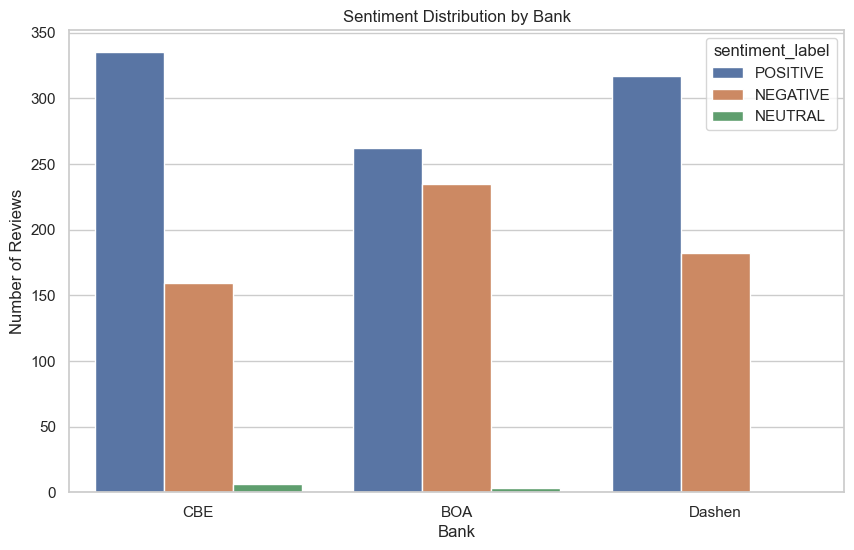

In [38]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='bank',
    hue='sentiment_label'
)

plt.title('Sentiment Distribution by Bank')

plt.xlabel('Bank')

plt.ylabel('Number of Reviews')

plt.xticks(rotation=0)

plt.show()

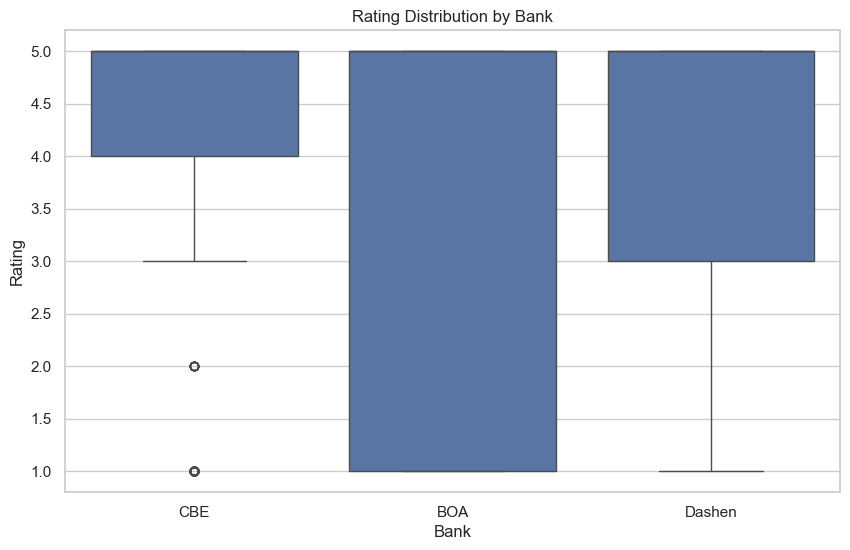

In [39]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='bank',
    y='rating'
)

plt.title('Rating Distribution by Bank')

plt.xlabel('Bank')

plt.ylabel('Rating')

plt.show()

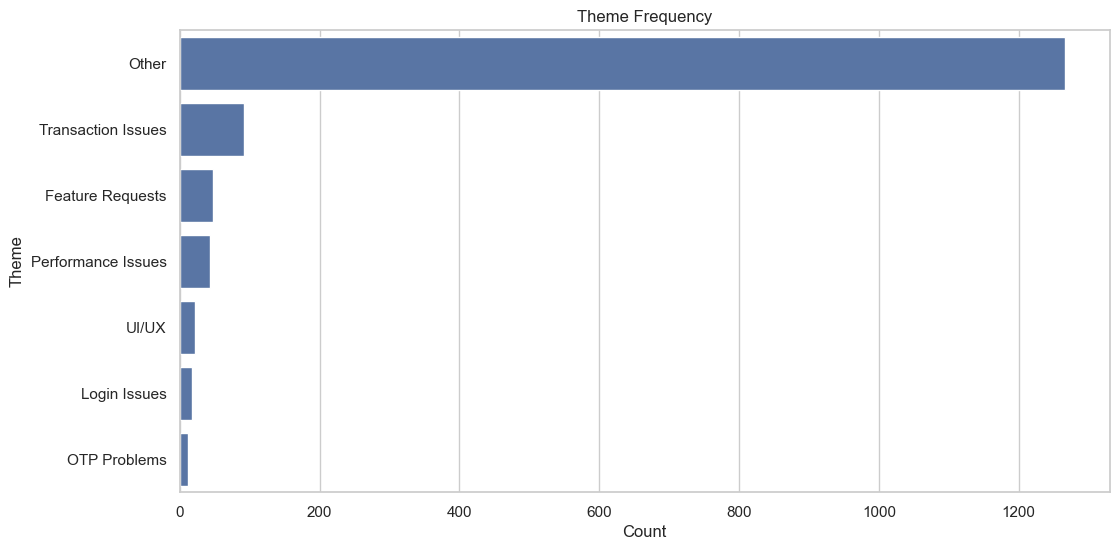

In [40]:
plt.figure(figsize=(12,6))

theme_counts = df['identified_theme'].value_counts()

sns.barplot(
    x=theme_counts.values,
    y=theme_counts.index
)

plt.title('Theme Frequency')

plt.xlabel('Count')

plt.ylabel('Theme')

plt.show()